# Workshop Template: Python Basics, Merging & Visualization

This notebook contains the exercises for the workshop, covering Python basics, data reading, merging, and basic visualization. Fill in the code where indicated by `# YOUR CODE HERE`.

# Section 0: Python Basics

## 0.1 String and Number

In [1]:
# Define a string and a number
my_string = "Data Science for Public Policy"
my_number = 2026
print(f"String: {my_string}")
print(f"Number: {my_number}")

String: Data Science for Public Policy
Number: 2026


## 0.2 List

In [2]:
# Create a list and append a new item
my_list = ["USA", "CAN"]
my_list.append("MEX")
print(f"List: {my_list}")

List: ['USA', 'CAN', 'MEX']


## 0.3 Dictionary

In [3]:
# Create a dictionary and look up a key
# YOUR CODE HERE (Keys: USA, CAN, MEX; Values: Washington D.C., Ottawa, Mexico City)
my_dict = {
    "USA": "Washington D.C.",
    "CAN": "Ottawa",
    "MEX": "Mexico City",
}
print(f"Capital of CAN: {my_dict['CAN']}")

Capital of CAN: Ottawa


# Section 1: Reading & Merging Data

## 1.1 Reading CSV Files

#### Data Source
The CSV data used in this section comes from the World Bank API. The original file is downloaded and cached locally at `data/examples/week_2/world_bank_data.csv` (relative to the project root directory).

Load the CSV file and display the first 3 rows.

In [4]:
import pandas as pd

# Load the CSV file
df_csv = pd.read_csv("../../../data/examples/week_2/world_bank_data.csv")
df_csv.head(3)

,Unnamed: 0,indicator,country,countryiso3code,date,value
0,0,GDP per capita (current US$),Canada,CAN,2023,53431.185706
1,1,GDP per capita (current US$),Canada,CAN,2022,55509.393176
2,2,GDP per capita (current US$),Canada,CAN,2021,52496.844169


## 1.2 Downloading Data via API

#### Data Source
The data in this section is downloaded live from the World Bank API (`https://api.worldbank.org/v2/`).

Use the World Bank API download helper to download total population data.

In [5]:
import requests
import io

def download_worldbank(indicator, countries, date_start, date_end):
    url_base = 'https://api.worldbank.org/v2/'
    country_codes = ';'.join(countries)
    url = f'{url_base}country/{country_codes}/indicator/{indicator}?date={date_start}:{date_end}&per_page=30000'
    response = requests.get(url)
    df = pd.read_xml(io.BytesIO(response.content))
    return df

### 1.2.1 Download Population Data

Download population (`SP.POP.TOTL`) for `['US', 'CA', 'MX']` from `2020` to `2023` and display the last 3 rows.

In [6]:
# Download population data
df_api = download_worldbank(indicator='SP.POP.TOTL', countries=['US','CA','MX'], date_start='2020', date_end='2023')
df_api.tail(3)

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
9,"Population, total",United States,USA,2022,333996304,NaN,NaN,0
10,"Population, total",United States,USA,2021,332100166,NaN,NaN,0
11,"Population, total",United States,USA,2020,331578104,NaN,NaN,0


## 1.3 Merging Datasets

#### Data Source
This section merges the locally loaded CSV dataset (which contains GDP per capita) with the live API dataset (which contains total population).

Merge the two DataFrames on `country` and `year`. Make sure the column names match before merging.

In [ ]:
# Clean CSV DataFrame (Rename value to gdp_per_capita and date to year, select country, year, gdp_per_capita)
df_csv_clean = df_csv.rename(columns={"value":"gdp_per_capita", "date":"year"})[["country","year","gdp_per_capita"]]

# Clean API DataFrame (Rename value to population and date to year, select country, year, population)
df_api_clean = df_api.rename(columns={"value":"population", "date":"year"})[["country","year","population"]]

# Merge datasets
df_merged = pd.merge(df_csv_clean, df_api_clean, on=["country", "year"])
df_merged.head(4)

,country,year,gdp_per_capita,population
0,Canada,2023,53431.185706,40049088
1,Canada,2022,55509.393176,38950132
2,Canada,2021,52496.844169,38239864
3,Mexico,2023,13790.024343,129739759


# Section 2: Data Manipulation & Visualization

## 2.1 Select Columns

Select only `country`, `year`, and `gdp_per_capita` columns from the merged dataset.

In [8]:
# Select specific columns
df_select = df_merged[["country","year","gdp_per_capita"]]
df_select.head(3)

,country,year,gdp_per_capita
0,Canada,2023,53431.185706
1,Canada,2022,55509.393176
2,Canada,2021,52496.844169


## 2.2 Filter Rows

Filter the rows where the country name is `Mexico`.

In [9]:
# Filter rows using query
df_filter = df_select.query("country == 'Mexico'")
df_filter.head(3)

,country,year,gdp_per_capita
3,Mexico,2023,13790.024343
4,Mexico,2022,11385.407076
5,Mexico,2021,10314.050674


## 2.3 Rename Columns

Rename `gdp_per_capita` to `gdp`.

In [10]:
# Rename columns
df_rename = df_filter.rename(columns={"gdp_per_capita":"gdp"})
df_rename.head()

,country,year,gdp
3,Mexico,2023,13790.024343
4,Mexico,2022,11385.407076
5,Mexico,2021,10314.050674


## 2.4 Visualization Basics

#### Data Source
The visualization uses the merged dataset containing both GDP per capita and population for Canada, Mexico, and the United States.

Plot the mean population by country using a bar chart. Save the plot under `reports/viz/` directory.

Plot saved successfully.


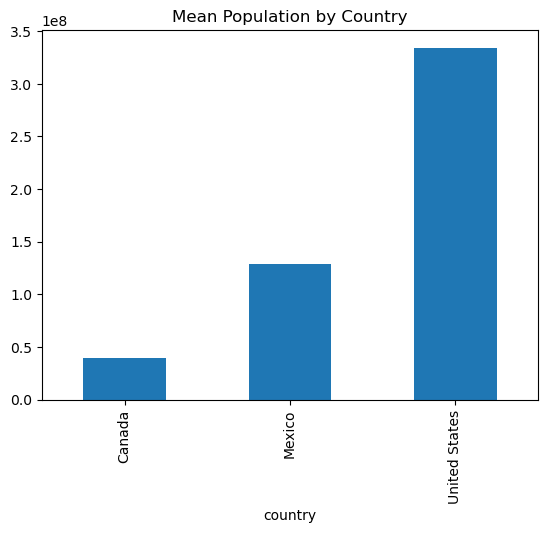

In [11]:
import matplotlib.pyplot as plt
import os

# Calculate mean population by country
mean_pop = df_merged.groupby('country')['population'].mean()

# Plot bar chart
plt.figure()
mean_pop.plot(kind="bar")
plt.title("Mean Population by Country")

# Create parent directories and save the plot
os.makedirs("reports/viz", exist_ok=True)
plt.savefig("reports/viz/timeseries.png")
print("Plot saved successfully.")